# Trend-Stationarity Exploration — Q1 Spread Tracking

The ADF + KPSS tests produced a conflicting result: ADF rejected a unit root (stationary) while KPSS rejected stationarity. This notebook investigates whether the spread has a genuine deterministic trend or experienced one or more structural breaks in its mean level.

**Steps:**
1. Visual inspection — spread + rolling mean
2. ADF + KPSS with trend term (`regression='ct'`)
3. Zivot-Andrews test — single structural break at unknown date
4. Bai-Perron test — multiple structural breaks
5. Split at break dates and re-test stationarity within each regime

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews

warnings.filterwarnings('ignore')
sys.path.insert(0, '../../..')

from src.data.loader import load_all
from src.features.engineering import create_features

df   = load_all()
wide = create_features(df)
spread = wide['spread_vs_net'].dropna()
aave   = wide['aave_apyBase'].dropna()
comp   = wide['compound_net'].dropna()

print(f'Spread series: {len(spread):,} days | {spread.index.min().date()} → {spread.index.max().date()}')
print(f'Range: {spread.min():.2f}% to {spread.max():.2f}% | Mean: {spread.mean():.4f}% | Std: {spread.std():.4f}%')

Spread series: 1,159 days | 2023-02-06 → 2026-04-13
Range: -16.32% to 54.18% | Mean: 0.3189% | Std: 2.8070%


## Step 1 — Visual Inspection

Plot the spread alongside its 30-day and 90-day rolling means. A smooth drift suggests a genuine trend; sudden level shifts suggest structural breaks.

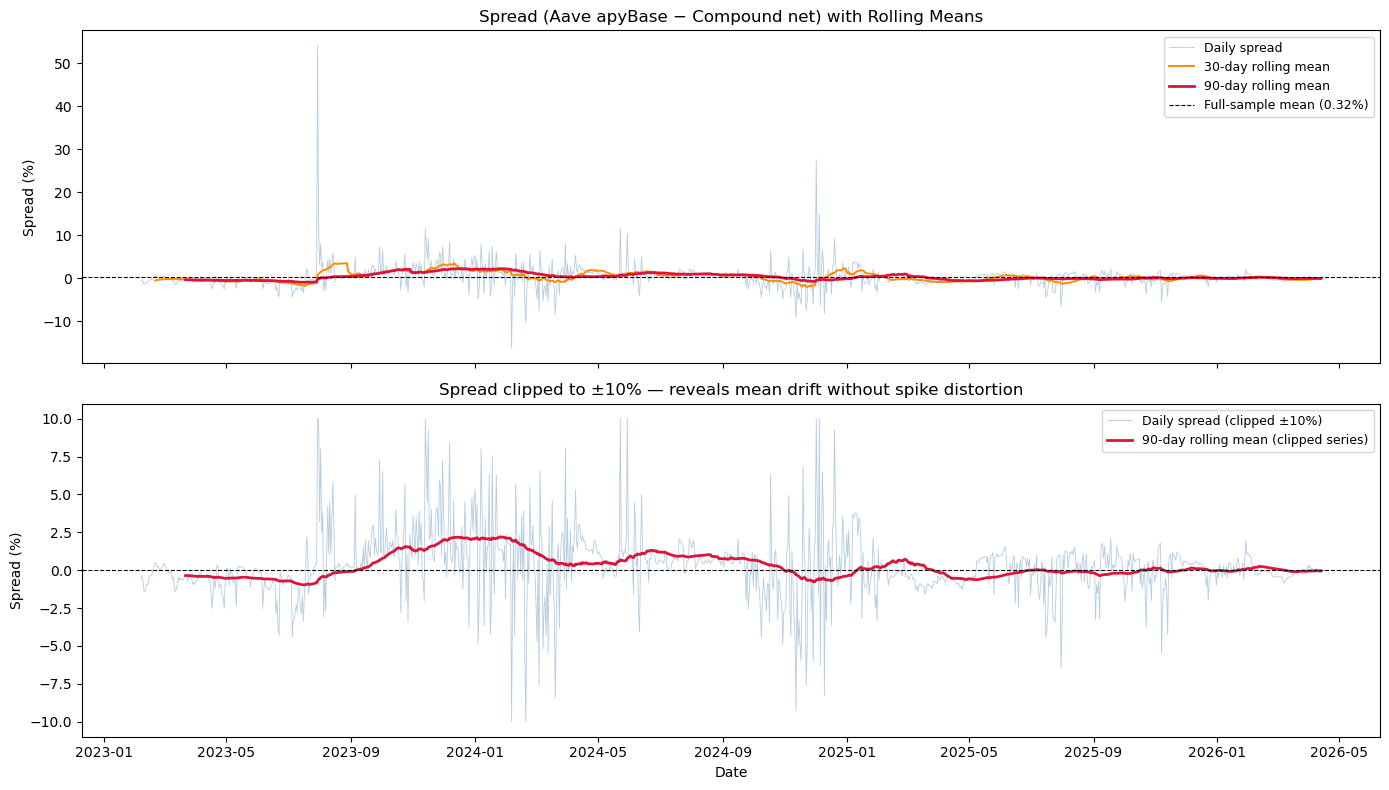

In [2]:
roll30 = spread.rolling(30,  min_periods=15).mean()
roll90 = spread.rolling(90,  min_periods=45).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Full spread series + rolling means
axes[0].plot(spread.index, spread.values, color='steelblue', alpha=0.4, linewidth=0.6, label='Daily spread')
axes[0].plot(roll30.index, roll30.values, color='darkorange', linewidth=1.4, label='30-day rolling mean')
axes[0].plot(roll90.index, roll90.values, color='crimson',    linewidth=2.0, label='90-day rolling mean')
axes[0].axhline(spread.mean(), color='black', linestyle='--', linewidth=0.8, label=f'Full-sample mean ({spread.mean():.2f}%)')
axes[0].set_title('Spread (Aave apyBase − Compound net) with Rolling Means', fontsize=12)
axes[0].set_ylabel('Spread (%)')
axes[0].legend(fontsize=9)

# Clip to ±10% to see the mean drift without spike distortion
spread_clipped = spread.clip(-10, 10)
roll90_clipped = spread_clipped.rolling(90, min_periods=45).mean()
axes[1].plot(spread_clipped.index, spread_clipped.values, color='steelblue', alpha=0.4, linewidth=0.6, label='Daily spread (clipped ±10%)')
axes[1].plot(roll90_clipped.index, roll90_clipped.values, color='crimson', linewidth=2.0, label='90-day rolling mean (clipped series)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Spread clipped to ±10% — reveals mean drift without spike distortion', fontsize=12)
axes[1].set_ylabel('Spread (%)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 2 — ADF + KPSS with Trend Term (`regression='ct'`)

Re-run both tests with `regression='ct'` (constant + linear trend). If KPSS fails to reject stationarity under this specification, the series is trend-stationary in the strict sense — there is a linear drift but residuals around that trend are stationary.

In [3]:
def run_adf_kpss(series, regression, label):
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(series.values, regression=regression, autolag='AIC')
    kpss_stat, kpss_p, kpss_lags, kpss_crit   = kpss(series.values, regression=regression, nlags='auto')

    adf_stationary  = adf_p  < 0.05
    kpss_stationary = kpss_p > 0.05

    if adf_stationary and kpss_stationary:
        conclusion = 'Stationary'
    elif not adf_stationary and not kpss_stationary:
        conclusion = 'Non-stationary'
    elif adf_stationary and not kpss_stationary:
        conclusion = 'Conflicting (trend-stationary)'
    else:
        conclusion = 'Inconclusive'

    print(f'--- {label} (regression={regression!r}) ---')
    print(f'ADF:  stat={adf_stat:.4f}  p={adf_p:.4f}  crit_5%={adf_crit["5%"]:.4f}  lags={adf_lags}')
    print(f'KPSS: stat={kpss_stat:.4f}  p={kpss_p:.4f}  crit_5%={kpss_crit["5%"]:.4f}  lags={kpss_lags}')
    print(f'Conclusion: {conclusion}\n')
    return conclusion

print('=== Original result (regression=c) ===')
run_adf_kpss(spread, 'c', 'Spread (constant only)')

print('=== With linear trend (regression=ct) ===')
run_adf_kpss(spread, 'ct', 'Spread (constant + trend)')

=== Original result (regression=c) ===
--- Spread (constant only) (regression='c') ---
ADF:  stat=-5.9850  p=0.0000  crit_5%=-2.8641  lags=12
KPSS: stat=0.6422  p=0.0188  crit_5%=0.4630  lags=13
Conclusion: Conflicting (trend-stationary)

=== With linear trend (regression=ct) ===
--- Spread (constant + trend) (regression='ct') ---
ADF:  stat=-6.1260  p=0.0000  crit_5%=-3.4143  lags=12
KPSS: stat=0.2494  p=0.0100  crit_5%=0.1460  lags=13
Conclusion: Conflicting (trend-stationary)



'Conflicting (trend-stationary)'

## Step 3 — Zivot-Andrews Test (Single Structural Break)

A variant of ADF that allows for a single structural break at an unknown date. Searches all possible break dates and selects the one that most strongly rejects the unit root null. The identified break date is the key diagnostic — if it aligns with a known protocol or market event, it strongly supports the structural break interpretation.

Zivot-Andrews statistic: -7.6084
p-value:                 0.0010
Critical values:         1%=-5.5756  5%=-5.0733  10%=-4.8267
Identified break date:   2023-07-17
Break index:             161 of 1159
Reject unit root:        True


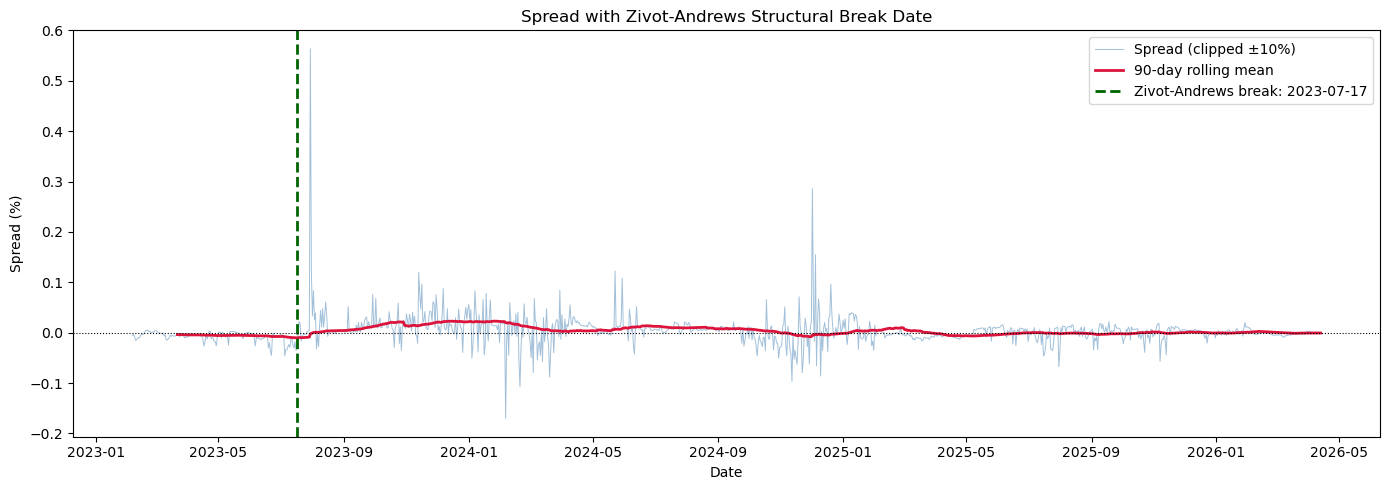

In [4]:
# Run Zivot-Andrews — regression='ct' allows break in intercept and trend
za_stat, za_p, za_crit, za_baselag, za_breakidx = zivot_andrews(
    spread.values, trim=0.10, regression='ct', autolag='AIC'
)

break_date = spread.index[za_breakidx]

print(f'Zivot-Andrews statistic: {za_stat:.4f}')
print(f'p-value:                 {za_p:.4f}')
print(f'Critical values:         1%={za_crit["1%"]:.4f}  5%={za_crit["5%"]:.4f}  10%={za_crit["10%"]:.4f}')
print(f'Identified break date:   {break_date.date()}')
print(f'Break index:             {za_breakidx} of {len(spread)}')
print(f'Reject unit root:        {za_stat < za_crit["5%"]}')

# Plot break date on the spread series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spread.index, spread.clip(-10, 10).values, color='steelblue', alpha=0.5, linewidth=0.7, label='Spread (clipped ±10%)')
ax.plot(spread.rolling(90, min_periods=45).mean().index,
        spread.clip(-10,10).rolling(90, min_periods=45).mean().values,
        color='crimson', linewidth=2.0, label='90-day rolling mean')
ax.axvline(break_date, color='darkgreen', linewidth=2.0, linestyle='--',
           label=f'Zivot-Andrews break: {break_date.date()}')
ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
ax.set_title('Spread with Zivot-Andrews Structural Break Date', fontsize=12)
ax.set_ylabel('Spread (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Bai-Perron Test (Multiple Structural Breaks)

Extends Zivot-Andrews to search for the optimal number of break points simultaneously. Implemented here as a least-squares breakpoint search: for k=1,2,3 breaks, find the partition that minimises total residual sum of squares (RSS), then use BIC to select the optimal number of breaks.

k=1: break indices=[163]  dates=[datetime.date(2023, 7, 19)]  RSS=0.96  BIC=-8205.58
k=2: break indices=[174, 363]  dates=[datetime.date(2023, 7, 30), datetime.date(2024, 2, 6)]  RSS=0.90  BIC=-8276.99
k=3: break indices=[174, 342, 593]  dates=[datetime.date(2023, 7, 30), datetime.date(2024, 1, 16), datetime.date(2024, 9, 23)]  RSS=0.89  BIC=-8284.02

Optimal breaks by BIC: k=3


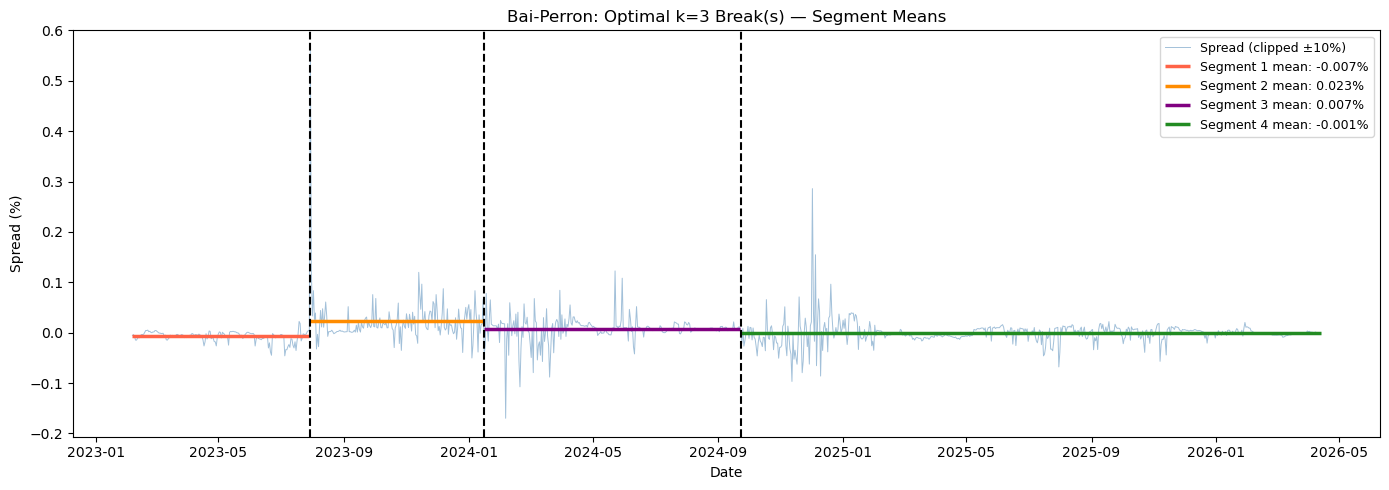

In [5]:
def segment_rss(series: np.ndarray) -> float:
    """RSS of fitting a constant (mean) to a segment."""
    return float(np.sum((series - series.mean()) ** 2))

def find_breakpoints_dp(series: np.ndarray, n_breaks: int, min_size: int = 60) -> tuple[list[int], float]:
    """
    Find n_breaks indices minimising total RSS using dynamic programming.
    O(n^2 * n_breaks) — fast for any reasonable n and k.
    """
    n = len(series)

    # Precompute RSS for every segment [i, j)
    rss = np.zeros((n, n))
    for i in range(n):
        for j in range(i + min_size, n):
            seg = series[i:j]
            rss[i, j] = np.sum((seg - seg.mean()) ** 2)

    # DP: dp[k][i] = min total RSS using k breaks, last segment ends at i
    INF = np.inf
    dp   = [[INF] * n for _ in range(n_breaks + 1)]
    path = [[-1]  * n for _ in range(n_breaks + 1)]

    # k=0: no breaks, single segment from 0 to i
    for i in range(min_size, n):
        dp[0][i] = rss[0][i]

    # Fill for k=1..n_breaks
    for k in range(1, n_breaks + 1):
        for i in range((k + 1) * min_size, n):
            for j in range(k * min_size, i - min_size + 1):
                cost = dp[k - 1][j] + rss[j][i]
                if cost < dp[k][i]:
                    dp[k][i] = cost
                    path[k][i] = j

    # Backtrack to recover break indices
    best_rss = dp[n_breaks][n - 1]
    breaks = []
    idx = n - 1
    for k in range(n_breaks, 0, -1):
        idx = path[k][idx]
        breaks.append(idx)
    breaks = sorted(breaks)

    return breaks, best_rss


values = spread.clip(-10, 10).values
n      = len(values)

results_bp = {}
for k in range(1, 4):
    breaks, rss = find_breakpoints_dp(values, k)
    bic = n * np.log(rss / n) + (k + 1) * np.log(n)
    results_bp[k] = {'breaks': breaks, 'rss': rss, 'bic': bic}
    dates = [spread.index[b].date() for b in breaks]
    print(f'k={k}: break indices={breaks}  dates={dates}  RSS={rss:.2f}  BIC={bic:.2f}')

best_k = min(results_bp, key=lambda k: results_bp[k]['bic'])
print(f'\nOptimal breaks by BIC: k={best_k}')
best_break_indices = results_bp[best_k]['breaks']
best_break_dates   = [spread.index[b] for b in best_break_indices]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spread.index, spread.clip(-10, 10).values, color='steelblue', alpha=0.5, linewidth=0.7, label='Spread (clipped ±10%)')

pts = [0] + best_break_indices + [len(spread)]
colors = ['tomato', 'darkorange', 'purple', 'forestgreen']
for i in range(len(pts) - 1):
    seg = spread.iloc[pts[i]:pts[i+1]]
    ax.hlines(seg.mean(), seg.index[0], seg.index[-1],
              color=colors[i % len(colors)], linewidth=2.5, label=f'Segment {i+1} mean: {seg.mean():.3f}%')

for d in best_break_dates:
    ax.axvline(d, color='black', linewidth=1.5, linestyle='--')

ax.set_title(f'Bai-Perron: Optimal k={best_k} Break(s) — Segment Means', fontsize=12)
ax.set_ylabel('Spread (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Step 5 — Re-test Stationarity Within Each Regime

Split the spread at the Bai-Perron break dates and run ADF + KPSS independently on each sub-series. If each segment is individually stationary, the trend-stationarity is fully explained by level shifts between stable regimes — not a genuine time trend.

In [6]:
all_break_indices = sorted(best_break_indices)
segment_bounds    = [0] + all_break_indices + [len(spread)]

print(f'Testing stationarity within {len(segment_bounds)-1} regime(s)\n')
print(f'{"Segment":<12} {"Date range":<35} {"N":>5}  {"Mean":>7}  {"ADF p":>7}  {"KPSS p":>7}  {"Conclusion"}')
print('-' * 100)

for i in range(len(segment_bounds) - 1):
    seg    = spread.iloc[segment_bounds[i]:segment_bounds[i+1]]
    label  = f'{seg.index[0].date()} → {seg.index[-1].date()}'

    if len(seg) < 30:
        print(f'Segment {i+1}   {label:<35} {len(seg):>5}  -- too short to test --')
        continue

    adf_stat, adf_p, *_ = adfuller(seg.values, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(seg.values, regression='c', nlags='auto')

    adf_ok  = adf_p  < 0.05
    kpss_ok = kpss_p > 0.05

    if adf_ok and kpss_ok:
        conclusion = 'Stationary ✓'
    elif not adf_ok and not kpss_ok:
        conclusion = 'Non-stationary'
    elif adf_ok and not kpss_ok:
        conclusion = 'Conflicting'
    else:
        conclusion = 'Inconclusive'

    print(f'Segment {i+1}   {label:<35} {len(seg):>5}  {seg.mean():>7.4f}  {adf_p:>7.4f}  {kpss_p:>7.4f}  {conclusion}')

print('\nIf all segments are stationary, trend-stationarity is explained by level shifts — not a genuine trend.')

Testing stationarity within 4 regime(s)

Segment      Date range                              N     Mean    ADF p   KPSS p  Conclusion
----------------------------------------------------------------------------------------------------
Segment 1   2023-02-06 → 2023-07-29               174  -0.0072   0.0000   0.0508  Stationary ✓
Segment 2   2023-07-30 → 2024-01-15               168   0.0227   0.0000   0.1000  Stationary ✓
Segment 3   2024-01-16 → 2024-09-22               251   0.0074   0.0232   0.1000  Stationary ✓
Segment 4   2024-09-23 → 2026-04-13               566  -0.0010   0.0002   0.1000  Stationary ✓

If all segments are stationary, trend-stationarity is explained by level shifts — not a genuine trend.
